In [2]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

In [3]:
def return_mass_plot(sim: str, sim_dir: str, smoothing: bool = True):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    sim_code_file = sim_dir + "simulation_codes.json"
    with open(sim_code_file, "r") as file:
        sim_codes = json.load(file)
    main_halo = sim_codes[sim]["halo"]
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    halt = gc_utils.get_halo_tree(sim, sim_dir)

    halo_idx = np.where(halt["tid"] == main_halo)[0][0]
    dm_mass_z0 = halt["mass"][halo_idx]
    mass_z0 = dm_mass_z0 / (1 - fb)

    time_lst = [0]
    mass_ratio_lst = [0]
    for snap in range(10, 601):
        time = all_snaps[all_snaps["index"] == snap]["time_Gyr"].values[0]

        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        halo_idx = np.where(halt["tid"] == halo_tid)[0][0]
        dm_mass = halt["mass"][halo_idx]
        mass = dm_mass / (1 - fb)
        mass_ratio = mass / mass_z0

        time_lst.append(time)
        mass_ratio_lst.append(mass_ratio)

    if smoothing:
        mass_ratio_lst = savgol_filter(mass_ratio_lst, window_length=50, polyorder=3)

    grp_file = sim_dir + sim + "/" + "gc_groups.json"
    with open(grp_file, "r") as file:
        grp_dict = json.load(file)
    # grp_lst = [int(grp) for grp in grp_dict[sim].keys() if int(grp) != 0]

    # acc_dict = {grp: {} for grp in grp_lst}
    acc_dict = {int(grp): {} for grp in grp_dict[sim].keys() if int(grp) != 0}

    for grp in acc_dict.keys():
        grp_idx = np.where(halt["tid"] == grp)[0][0]
        grp_snp = halt["snapshot"][grp_idx]
        grp_tim = all_snaps[all_snaps["index"] == grp_snp + 1]["time_Gyr"].values[0]
        acc_dict[grp] = grp_tim

    return mass_ratio_lst, time_lst, acc_dict

In [4]:
def return_kappa_co(sim, sim_dir, spec_type="s"):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    kin_file = sim_dir + sim + "/" + "galaxy_kinematics.json"
    with open(kin_file, "r") as file:
        kin_dict = json.load(file)

    time_lst = []
    kappa_co_lst = []
    for snap_id in kin_dict.keys():
        snp = int(snap_id[4:])
        tim = all_snaps[all_snaps["index"] == snp]["time_Gyr"].values[0]
        time_lst.append(tim)

        if spec_type == "s":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_s"])

        elif spec_type == "g":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_g"])

        elif spec_type == "sg":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_sg"])

        else:
            raise Warning("Wrong spec_type chosen")

    return time_lst, kappa_co_lst

Retrieving Halo Tree.....................: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [01:55<00:00, 115.42s/it]


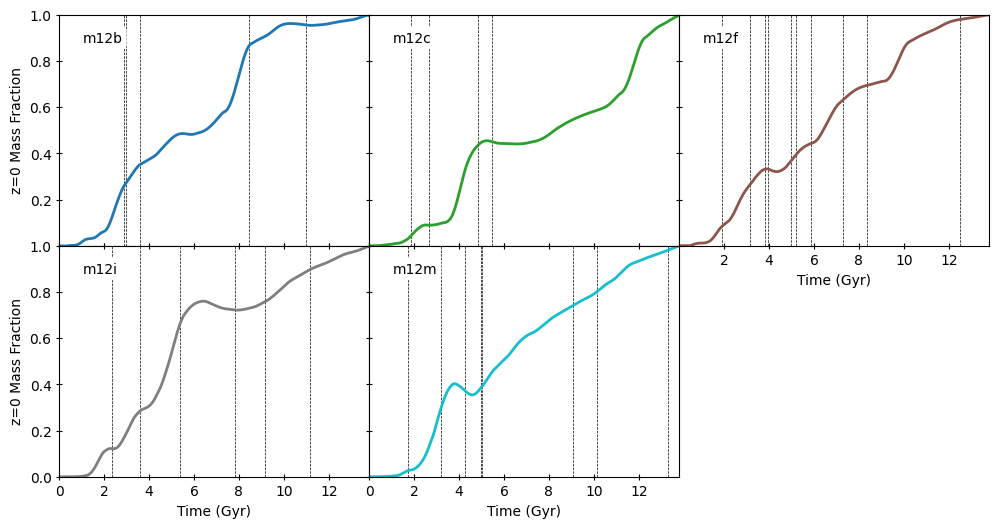


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12m/m12m_res7100/snapshot_times.txt

* input redshift = 0:  using snapshot index = 600, redshift = 0.000

* read 81252 halos from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/halo_600.hdf5

# in halo_analysis.halo_io.Particle():
* read 81252 halos, 143 have star particles, from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/star_600.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished



In [4]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i", "m12i", "m12i", "m12i", "m12i"]
# sim_lst = ["m12i", "m12f"]

# sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/One_Touch/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

nrows = 2
ncols = 3

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0, wspace=0)

xticks = [0, 2, 4, 6, 8, 10, 12]
yticks = [0, 0.2, 0.4, 0.6, 0.8, 1]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

for i, ax in enumerate(axs.flatten()):
    if i == len(sim_lst):
        ax.axis("off")
        continue
    sim = sim_lst[i]

    mass_ratio_lst, time_lst, acc_dict = return_mass_plot(sim, sim_dir, smoothing=True)

    ax.plot(time_lst, mass_ratio_lst, c=colors[i], lw=2)

    for grp in acc_dict:
        ax.plot([acc_dict[grp], acc_dict[grp]], [0, 1], c="k", ls="--", lw=0.5, zorder=0)

    ax.set_xlim(0, np.max(time_lst))
    ax.set_ylim(0, 1)

    # ax.text(
    #     0.075,
    #     0.9,
    #     sim,
    #     horizontalalignment="left",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=10,
    # )

    ax.text(
        0.075,
        0.9,
        sim,
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",  # background color
            edgecolor="none",  # no border
            boxstyle="round,pad=0.3",
        ),
    )

    if (i == 0) or (i == 3):
        ax.set_ylabel("z=0 Mass Fraction")

        if i == 0:
            ax.set_yticks(yticks[1:])

    else:
        ax.set_yticklabels([])

    if i < 2:
        ax.set_xticklabels([])

    if i == 2:
        ax.set_xticks(xticks[1:])

    if i < 3:
        ax.tick_params(axis="x", which="major", direction="inout", bottom=True, top=False, length=4)
    else:
        ax.tick_params(axis="x", which="major", direction="inout", bottom=True, top=True, length=4)

    ax.tick_params(axis="y", which="major", direction="inout", left=True, right=False, length=4)

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")

    kappa_dict = {
        "m12b": {"kappa_015": 4.6, "kappa_02": 5.3, "kappa_04": 6.9},
        "m12c": {"kappa_015": 6.6, "kappa_02": 6.8, "kappa_04": 8.5},
        "m12f": {"kappa_015": 3.6, "kappa_02": 3.85, "kappa_04": 6.9},
        "m12i": {"kappa_015": 6.43, "kappa_02": 6.6, "kappa_04": 8.4},
        "m12m": {"kappa_015": 3.4, "kappa_02": 3.56, "kappa_04": 4.0},
    }

    kap02 = kappa_dict[sim_lst[i]]["kappa_02"]
    kap04 = kappa_dict[sim_lst[i]]["kappa_04"]

    # ax.plot([kap02, kap02], [0, 1], c="r", ls="--", lw=0.75, zorder=0)
    # ax.plot([kap04, kap04], [0, 1], c="r", ls="--", lw=0.75, zorder=0)

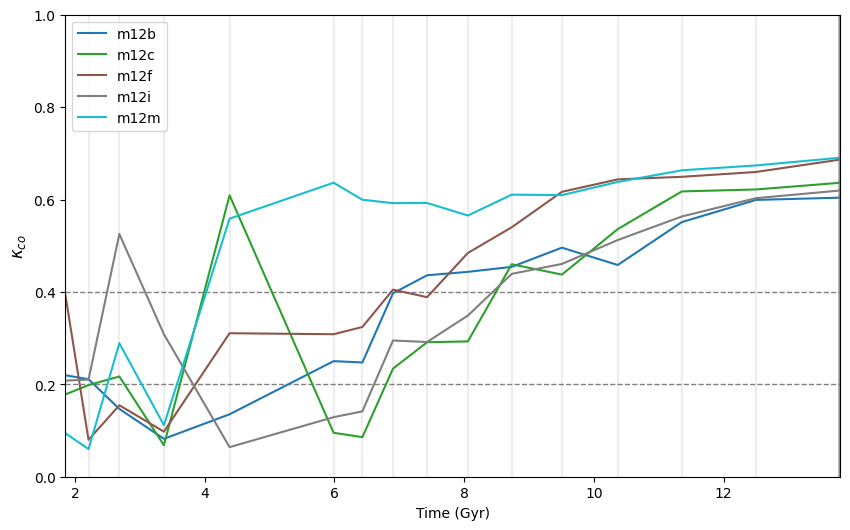

In [ ]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
# sim_dir = "/Volumes/My_passport_for_Mac/simulations/"
# sim_dir = "/Volumes/One_Touch/simulations/"

plt.figure(figsize=(10, 6))

# cmap = plt.get_cmap("cool")
# cmap = plt.get_cmap("jet")
cmap = plt.get_cmap("tab10")

colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

for i, sim in enumerate(sim_lst):
    # currently set to kappa_co of stars and cold gas
    time_lst, kappa_co_lst = return_kappa_co(sim, sim_dir, spec_type="sg")
    # kappa_co_lst = savgol_filter(kappa_co_lst, window_length=10, polyorder=5)
    plt.plot(time_lst, kappa_co_lst, c=colors[i], lw=1.5, label=sim)
    # plt.plot(time_lst, kappa_co_lst, c="k", lw=1.5, label=sim)

plt.legend(loc="upper left")

plt.xlim(np.min(time_lst), np.max(time_lst))
plt.ylim(0, 1)

plt.plot([np.min(time_lst), np.max(time_lst)], [0.4, 0.4], c="grey", ls="--", lw=1, zorder=0)
plt.plot([np.min(time_lst), np.max(time_lst)], [0.2, 0.2], c="grey", ls="--", lw=1, zorder=0)
# plt.plot([np.min(time_lst), np.max(time_lst)], [0.15, 0.15], c="grey", ls="--", lw=1, zorder=0)

################################################################################################

kappa_dict = {
    "m12b": {"kappa_015": 4.6, "kappa_02": 5.3, "kappa_04": 6.9},
    "m12c": {"kappa_015": 6.6, "kappa_02": 6.8, "kappa_04": 8.5},
    "m12f": {"kappa_015": 3.6, "kappa_02": 3.85, "kappa_04": 6.9},
    "m12i": {"kappa_015": 6.43, "kappa_02": 6.6, "kappa_04": 8.4},
    "m12m": {"kappa_015": 3.4, "kappa_02": 3.56, "kappa_04": 4.0},
}

# kapp_015 = kappa_dict[sim]["kappa_015"]
kapp_02 = kappa_dict[sim]["kappa_02"]
kapp_04 = kappa_dict[sim]["kappa_04"]

# plt.plot([kapp_015, kapp_015], [0, 1], c="g", ls="--", lw=1, zorder=0)
# plt.plot([kapp_02, kapp_02], [0, 1], c="r", ls="--", lw=1, zorder=0)
# plt.plot([kapp_04, kapp_04], [0, 1], c="r", ls="--", lw=1, zorder=0)

plt.xlabel("Time (Gyr)")
plt.ylabel(r"$\kappa_{co}$", fontsize=12)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

for time in pub_snaps["time_Gyr"]:
    plt.plot([time, time], [0, 1], c="grey", lw=0.2)

In [16]:
def crossings_scipy(x, y, threshold):
    # Find where sign changes (y-threshold crosses zero)
    sign_changes = np.where(np.diff(np.sign(y - threshold)) != 0)[0]
    if len(sign_changes) == 0:
        return []

    crossings = []
    for i in sign_changes:
        f = interp1d(y[i : i + 2], x[i : i + 2], kind="linear")
        crossings.append(float(f(threshold)))

    return crossings

In [33]:
for i, sim in enumerate(sim_lst):
    # currently set to kappa_co of stars and cold gas
    time_lst, kappa_co_lst = return_kappa_co(sim, sim_dir, spec_type="sg")

    time_lst = np.array(time_lst)
    kappa_co_lst = np.array(kappa_co_lst)

    kappa_03 = crossings_scipy(time_lst, kappa_co_lst, 0.3)

    kappa_03 = np.round(kappa_03, 2)
    print(sim, kappa_03)

m12b [6.6]
m12c [3.81 5.35 8.09]
m12f [1.72 1.96 4.33]
m12i [1.56 1.63 2.35 3.41 7.52]
m12m [3.8]


In [34]:
print("m12b", time_lst[-1] - 7.42)
print("m12c", time_lst[-1] - 6.49)
print("m12f", time_lst[-1] - 7.42)
print("m12i", time_lst[-1] - 6.65)
print("m12m", time_lst[-1] - 9.21)


m12b 6.378746883
m12c 7.3087468829999995
m12f 6.378746883
m12i 7.148746882999999
m12m 4.588746882999999


In [16]:
# crossings_scipy(time_lst, kappa_co_lst, 0.2)

for i, sim in enumerate(sim_lst):
    # currently set to kappa_co of stars and cold gas
    time_lst, kappa_co_lst = return_kappa_co(sim, sim_dir, spec_type="sg")

    time_lst = np.array(time_lst)
    kappa_co_lst = np.array(kappa_co_lst)

    kappa_02 = crossings_scipy(time_lst, kappa_co_lst, 0.2)
    kappa_04 = crossings_scipy(time_lst, kappa_co_lst, 0.4)

    # kappa_02 = np.round(kappa_02, 2)
    # kappa_04 = np.round(kappa_04, 2)

    # print(sim, np.max(kappa_02), np.max(kappa_04), np.round(np.max(kappa_04) - np.max(kappa_02),2))

    print(sim, kappa_02, kappa_04)

m12b [1.6400618863506418, 2.2921145860053898, 5.28869782731584] [6.9433774923597165]
m12c [2.2535624132751724, 2.7636964160841395, 3.6190945852169927, 5.66102374330574, 6.795641796705221] [3.99337563833136, 5.037038203564162, 8.491870497069701]
m12f [1.3093570197579374, 2.073719998928273, 3.8590276128534295] [6.874961421754058, 7.062571948979366, 7.50356475354914]
m12i [1.4284947860115595, 3.8214742047646397, 6.611946443235142] [2.4963977153345045, 3.0822917979287174, 8.441422433691756]
m12m [2.500895330525406, 3.0298206127851146, 3.572598417185062] [4.025468943177161]
